# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [7]:
best_N50 = {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}
best_N60 = {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 5e4}

## frank2d

In [8]:
N = 300

In [9]:
frank2d = Frank2D(N, rout, geom)

In [10]:
frank2d.process_vis(uvtable, hermitian = False)

===>  Setting gridded data...


In [11]:
uvtable_gridded = frank2d.gridded_data

In [12]:
u_syn = uvtable_gridded['u'].reshape(N, N)
v_syn = uvtable_gridded['v'].reshape(N, N)
vis_syn = uvtable_gridded['vis'].reshape(N, N)
weights_syn = uvtable_gridded['weights'].reshape(N, N)

Text(0, 0.5, 'v [λ]')

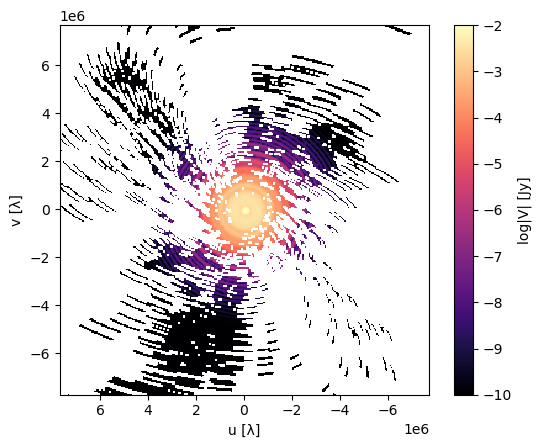

In [13]:
plt.imshow(np.log(np.abs(vis_syn)),
             extent=[u_syn.max(), u_syn.min(), v_syn.min(), v_syn.max()], 
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
#plt.title('Synthetic visibilities gridded by F2D', size=9)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

===>  Setting GP Kernel Wendland...
        + Kernel parameters:  {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}
===>  Creating sparse linear system...


        + time kernel = 0.02  min |  1.06 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.02  min |  1.09 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.003494244304975654
                       .... iteration:  0
                             -> actual tol  3.49e+07  versus  3.49e-03
                       .... iteration:  1
                             -> actual tol  2.97e+06  versus  3.49e-03
                       .... iteration:  2
                             -> actual tol  5.60e+06  versus  3.49e-03
                       .... iteration:  3
                             -> actual tol  2.27e+07  versus  3.49e-03
                       .... iteration:  4
                             -> actual tol  1.14e+06  versus  3.49e-03
                       .... iteration:  5
                             -> actual tol  1.64e+06  versus  3.49e-03
                       .... iteration: 

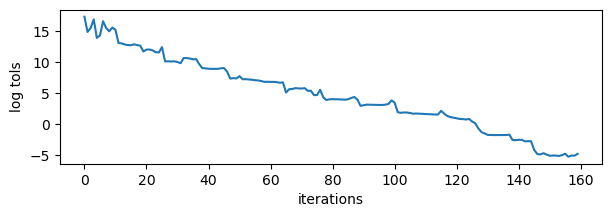

         + time BiCGStab = 0.03  min |  1.84 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.04  min |  2.39 seconds


xxxxxxxxxxxxxxxxxxxxxxxxx F2D took 0.09 minutes xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [14]:
start = time.time()

frank2d.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10)

end = time.time()
total_time = end - start
print("\n")
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D took {((end - start)/60):.2f} minutes xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

In [15]:
Plot_ = Plot(frank2d)

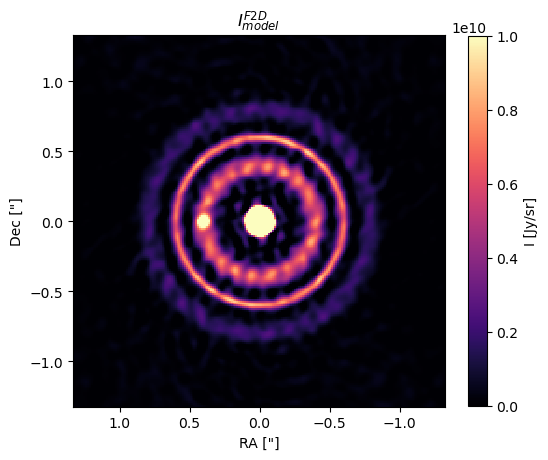

In [16]:
Plot_.intensity( vmax=1e10, gamma = 1, zoom = 1.5, title= r'$I_{model}^{F2D}$')

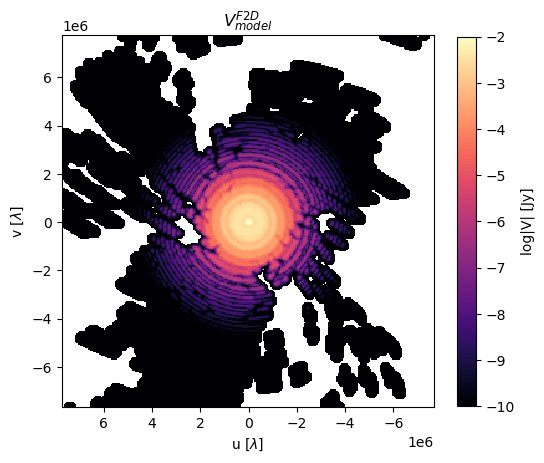

In [17]:
Plot_.visibility(fig_size = 6, title= r'$V_{model}^{F2D}$')

### With hermitian symmetry

In [18]:
frank2d2 = Frank2D(N, rout, geom)

In [19]:
frank2d2.process_vis(uvtable, hermitian = True)

===>  Setting gridded data...


In [20]:
uvtable_gridded_herm = frank2d2.gridded_data

In [21]:
u_syn_herm = uvtable_gridded_herm['u'].reshape(N, N)
v_syn_herm = uvtable_gridded_herm['v'].reshape(N, N)
vis_syn_herm = uvtable_gridded_herm['vis'].reshape(N, N)
weights_syn_herm = uvtable_gridded_herm['weights'].reshape(N, N)

Text(0, 0.5, 'v [λ]')

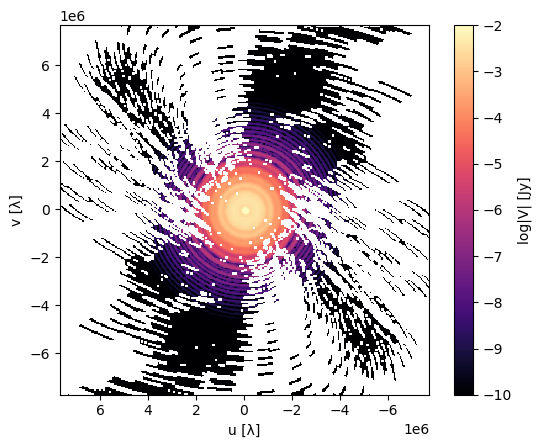

In [22]:
plt.imshow(np.log(np.abs(vis_syn_herm)),
             extent=[u_syn_herm.max(), u_syn_herm.min(), v_syn_herm.min(), v_syn_herm.max()],
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
#plt.title('Synthetic visibilities gridded by F2D', size=9)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

===>  Setting GP Kernel Wendland...
        + Kernel parameters:  {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}
===>  Creating sparse linear system...


        + time kernel = 0.03  min |  1.74 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.03  min |  1.78 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.012212677737961322
                       .... iteration:  0
                             -> actual tol  1.22e+08  versus  1.22e-02
                       .... iteration:  1
                             -> actual tol  9.67e+06  versus  1.22e-02
                       .... iteration:  2
                             -> actual tol  9.76e+06  versus  1.22e-02
                       .... iteration:  3
                             -> actual tol  5.12e+07  versus  1.22e-02
                       .... iteration:  4
                             -> actual tol  3.08e+06  versus  1.22e-02
                       .... iteration:  5
                             -> actual tol  3.89e+06  versus  1.22e-02
                       .... iteration: 

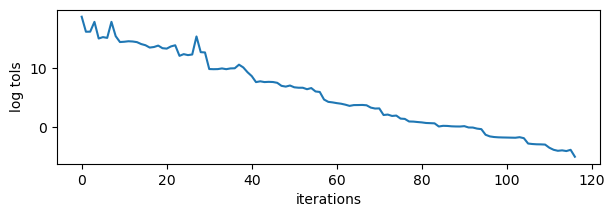

         + time BiCGStab = 0.04  min |  2.42 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.05  min |  2.89 seconds


xxxxxxxxxxxxxxxxxxxxxxxxx F2D hermitian took 0.12 minutes xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [23]:
start = time.time()
frank2d2.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10)
end = time.time()

print("\n")
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D hermitian took {((end - start)/60):.2f} minutes xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

In [24]:
Plot_2 = Plot(frank2d2)

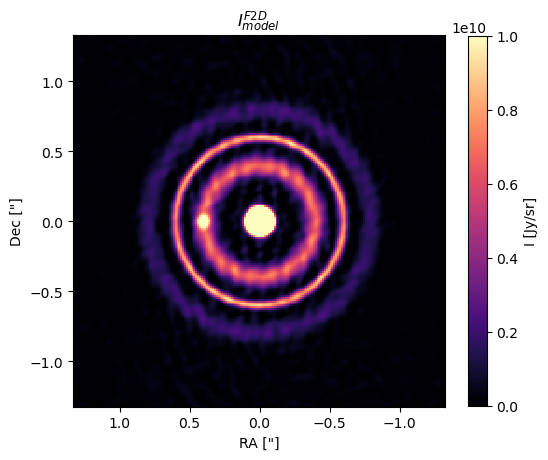

In [25]:
Plot_2.intensity(gamma = 1, zoom = 1.5,  vmax=1e10, title= r'$I_{model}^{F2D}$')

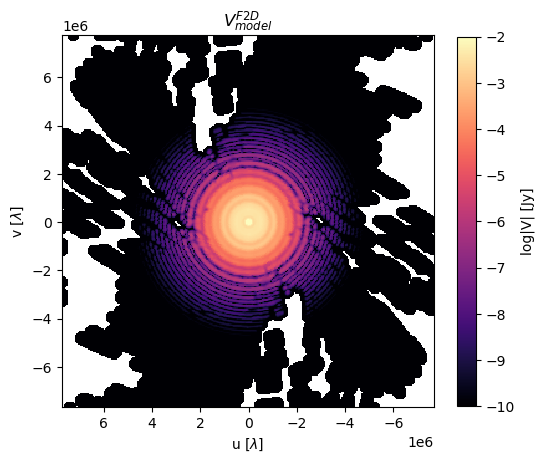

In [26]:
Plot_2.visibility(fig_size = 6, title= r'$V_{model}^{F2D}$')

## Difference

In [44]:
frank_object = frank2d

In [46]:
vis_f2d = frank_object.visibility_model
v_f2d_1d = frank_object.v
u_f2d_1d = frank_object.u

u_aim = uvtable['u']
v_aim = uvtable['v']
V_aim = uvtable['vis']
weights_aim = uvtable['weights']

In [47]:
v_f2d_1d.shape

(300,)

In [48]:
from scipy.interpolate import RegularGridInterpolator

model_grid_real = np.real(vis_f2d)
model_grid_imag = np.imag(vis_f2d)

interp_real = RegularGridInterpolator((u_f2d_1d, v_f2d_1d), model_grid_real,
                                      method='linear', bounds_error=False, fill_value=0.0)

interp_imag = RegularGridInterpolator((u_f2d_1d, v_f2d_1d), model_grid_imag,
                                      method='linear', bounds_error=False, fill_value=0.0)

uv_points_to_sample = np.stack((u_aim, v_aim), axis=-1)

V_model_real_sampled = interp_real(uv_points_to_sample)
V_model_imag_sampled = interp_imag(uv_points_to_sample)

V_f2d_degridded = V_model_real_sampled + 1j * V_model_imag_sampled


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#  CHI-SQUARED
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
residuals = V_aim - V_f2d_degridded

residuals_mag_sq = np.abs(residuals)**2

chi_squared_terms = weights_aim * residuals_mag_sq

chi_squared_total = np.sum(chi_squared_terms)

In [50]:
chi_squared_total_non_hermitian = 120425.14987889021

In [51]:
chi_squared_total_hermitian = 70896.52706752437


In [57]:
chi_non_hermitian = chi_squared_total_non_hermitian/(2*len(u_aim) - 2*(N**2))
chi_non_hermitian

0.0016400765080117378

In [58]:
chi_hermitian = chi_squared_total_hermitian/(2*len(u_aim) - N**2)
chi_hermitian

0.0009643615329295725